# Notebook to explore the Gene Expression data extracted from archs4 H5 file

ref [NIH](https://bioinformatics.ccr.cancer.gov/docs/b4b/RNASeq_Overview/01.Overview/)

Contains documentation for remapping and 
_____

Outputs file path: `/data/FinalExpression/{disease}/expressions(cleaned)/{GSEID}.tsv`

In [5]:
import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import archs4py as a4
import plotly.graph_objects as go
import colorsys
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from typing import Dict, Optional, List

os.getcwd()

'/Users/lingthang/JRaviLab/integrative-drugrep-tb/DataCurration'

## Initialize Variables

In [ ]:
# General Paths 
rnaRAW_path = '../data/RNAseq_data_forDE/expression_matrices/rawexpression/'
microRAW_path = '../data/microarray_data_forDE/expression_matrices/rawexpression/'

rnaRAW_metadata_path = '../data/RNAseq_data_forDE/metadata/'
microRAW_metadata_path = '../data/microarray_data_forDE/metadata/'

# verify that the paths exist
all_paths = [rnaRAW_path, microRAW_path, rnaRAW_metadata_path, microRAW_metadata_path]

for path in all_paths:
	if not os.path.exists(path):
		print(f"Path does not exist: {path}")
	else:
		print(f"Path exists: {path}")

Path exists: ../data/RNAseq_data_forDE/expression_matrices/rawexpression/
Path exists: ../data/microarray_data_forDE/expression_matrices/rawexpression/
Path exists: ../data/RNAseq_data_forDE/metadata/
Path exists: ../data/microarray_data_forDE/metadata/


In [10]:
rnaCLEAN_path = '../data/RNAseq_data_forDE/expression_matrices/cleaned'
microCLEAN_path = '../data/microarray_data_forDE/expression_matrices/cleaned'

# List all paths to be created
paths = [
    rnaCLEAN_path,
    microCLEAN_path,
]

# Create directories, creating intermediate ones as necessary.
# exist_ok=True prevents errors if the directory already exists.
for path in paths:
    os.makedirs(path, exist_ok=True)

#### Do all studies have metadata and expression data?

In [14]:
def metadata_expr_match(metadata_dir, expression_dir):
    """
    Returns True if every GSE in metadata_dir (as metadata_GSE########.tsv)
    matches every GSE in expression_dir (as GSE########.tsv),
    and there are no extra GSEs in either directory.
    """
    meta_ids = {
        f[len("metadata_"):-4]
        for f in os.listdir(metadata_dir)
        if f.startswith("metadata_GSE") and f.endswith(".tsv")
    }
    expr_ids = {
        f[:-4]
        for f in os.listdir(expression_dir)
        if f.startswith("GSE") and f.endswith(".tsv")
    }

    # Conditions:
    # 1. All IDs present in both
    # 2. No extras in either dir
    meta_missing = expr_ids - meta_ids
    expr_missing = meta_ids - expr_ids

    match = meta_ids == expr_ids

    if not match:
        print("Mismatch detected:")
        if meta_missing:
            print(f"Missing in metadata: {sorted(meta_missing)}")
        if expr_missing:
            print(f"Missing in expression: {sorted(expr_missing)}")
    return match

# Usage examples:
print("RNA:", metadata_expr_match(rnaRAW_metadata_path, rnaRAW_path))
print("Micro:", metadata_expr_match(microRAW_metadata_path, microRAW_path))

RNA: True
Micro: True


## Expression Data EDA

In [15]:
def get_expression_shape(path : str, shape : str = None):
    """
    returns the shape of the each file in the directory
    """
    last_dir = os.path.basename(os.path.normpath(path))
    print(f"Number of studies in {last_dir}: {len(os.listdir(path))}")
    
    files = os.listdir(path)
    for file in files:
        if file.endswith('.tsv'):
            df = pd.read_csv(os.path.join(path, file), sep='\t')
            if shape is None:
                print(f"{file}: {df.shape}")
            elif shape == 'rows':
                print(f"{file}: {df.shape[0]} rows")
            elif shape == 'columns':
                print(f"{file}: {df.shape[1]} columns")
            else:
                raise ValueError("Invalid shape argument. Use 'both', 'rows', or 'columns'.")

#### Get Expression File shape

In [16]:
get_expression_shape(rnaRAW_path)

Number of studies in rawexpression: 22
GSE236156.tsv: (67186, 36)
GSE164287.tsv: (67186, 9)
GSE148731.tsv: (67186, 25)
GSE183912.tsv: (67186, 9)
GSE211974.tsv: (67186, 7)
GSE132283.tsv: (67186, 13)
GSE165708.tsv: (67186, 33)
GSE143731.tsv: (67186, 9)
GSE174566.tsv: (67186, 37)
GSE256184.tsv: (67186, 17)
GSE141656.tsv: (67186, 7)
GSE223863.tsv: (67186, 29)
GSE193777.tsv: (67186, 47)
GSE148171.tsv: (67186, 10)
GSE64179.tsv: (67186, 13)
GSE198557.tsv: (67186, 13)
GSE143627.tsv: (67186, 7)
GSE112483.tsv: (67186, 84)
GSE121049.tsv: (67186, 7)
GSE84076.tsv: (67186, 11)
GSE64182.tsv: (67186, 7)
GSE112482.tsv: (67186, 88)


In [17]:
get_expression_shape(microRAW_path)

Number of studies in rawexpression: 10
GSE42834.tsv: (23374, 17)
GSE34151.tsv: (23374, 260)
GSE42830.tsv: (23374, 17)
GSE16250.tsv: (20056, 7)
GSE139871.tsv: (23552, 25)
GSE18794.tsv: (21661, 22)
GSE119143.tsv: (35066, 13)
GSE19491.tsv: (21799, 338)
GSE83456.tsv: (23374, 203)
GSE63548.tsv: (23371, 27)


## Gene Mapping Dictionary Set Up
<a id="GeneMapping"></a>

In [19]:
homo_gene = pd.read_csv(os.path.join("../data/metadata", "Homo_sapiens.gene_info.tsv"), sep = '\t')
homo_gene.head()

,Unnamed: 0,#tax_id,GeneID,Symbol,LocusTag,Synonyms,dbXrefs,chromosome,map_location,description,type_of_gene,Symbol_from_nomenclature_authority,Full_name_from_nomenclature_authority,Nomenclature_status,Other_designations,Modification_date,Feature_type,Ensembl
0,0,9606,1,A1BG,-,A1B|ABG|GAB|HYST2477,MIM:138670|HGNC:HGNC:5|Ensembl:ENSG00000121410...,19,19q13.43,alpha-1-B glycoprotein,protein-coding,A1BG,alpha-1-B glycoprotein,O,alpha-1B-glycoprotein|HEL-S-163pA|epididymis s...,20250819,-,ENSG00000121410
1,1,9606,2,A2M,-,A2MD|CPAMD5|FWP007|S863-7,MIM:103950|HGNC:HGNC:7|Ensembl:ENSG00000175899...,12,12p13.31,alpha-2-macroglobulin,protein-coding,A2M,alpha-2-macroglobulin,O,alpha-2-macroglobulin|C3 and PZP-like alpha-2-...,20250909,-,ENSG00000175899
2,2,9606,9,NAT1,-,AAC1|MNAT|NAT-1|NATI,MIM:108345|HGNC:HGNC:7645|Ensembl:ENSG00000171...,8,8p22,N-acetyltransferase 1,protein-coding,NAT1,N-acetyltransferase 1,O,arylamine N-acetyltransferase 1|N-acetyltransf...,20250909,-,ENSG00000171428
3,3,9606,10,NAT2,-,AAC2|NAT-2|PNAT,MIM:612182|HGNC:HGNC:7646|Ensembl:ENSG00000156...,8,8p22,N-acetyltransferase 2,protein-coding,NAT2,N-acetyltransferase 2,O,arylamine N-acetyltransferase 2|N-acetyltransf...,20250909,-,ENSG00000156006
4,4,9606,11,NATP,-,AACP|NATP1,HGNC:HGNC:15|AllianceGenome:HGNC:15,8,8p22,N-acetyltransferase pseudogene,pseudo,NATP,N-acetyltransferase pseudogene,O,arylamide acetylase pseudogene,20250819,-,NaN


In [ ]:
list(homo_gene.columns)

def extract_ensembl_id(dbxref):
    """
    Extracts the Ensembl ENSG ID from a dbXrefs string.
    Returns the ENSG ID if found, else returns None.
    """
    if pd.isna(dbxref):
        return None
    match = re.search(r'Ensembl:(ENSG[0-9]+)', str(dbxref))
    if match:
        return match.group(1)
    return None

# Apply to DataFrame column
homo_gene['Ensembl_ID'] = homo_gene['dbXrefs'].apply(extract_ensembl_id)
#--- save the file with Ensembl column
#homo_gene['Ensembl'] = homo_gene['dbXrefs'].apply(extract_ensembl_id)
#homo_gene.to_csv("/Users/kewalinsamart/Documents/GitHub/integrative-drugrep-tb/data/v2/metadata/Homo_sapiens.gene_info.tsv", sep = "\t")

# Build symbol+alias to Ensembl ID mapping
symbol_to_ensg = {}
for _, row in homo_gene.iterrows():
    ensg = row['Ensembl_ID']
    if pd.notna(ensg):
        # Add main symbol
        symbol_to_ensg[row['Symbol']] = ensg
        # Add aliases from Synonyms column (pipe or comma separated)
        if pd.notna(row['Synonyms']):
            for alias in str(row['Synonyms']).replace('|', ',').split(','):
                alias = alias.strip()
                if alias and alias != row['Symbol']:
                    symbol_to_ensg[alias] = ensg

print(f"Total unique symbol to Ensembl ID keys: {len(symbol_to_ensg)}")

symbol_alias = {}

# Build a symbol to alias mapping
for _, row in homo_gene.iterrows():
    symbol = row['Symbol']
    if pd.notna(symbol):
        symbol_alias[symbol] = symbol
        if pd.notna(row['Synonyms']):
            for alias in str(row['Synonyms']).replace('|', ',').split(','):
                alias = alias.strip()
                if alias and alias != symbol:
                    symbol_alias[alias] = symbol

print(f"Total unique symbol to alias keys: {len(symbol_alias)}")


gene_to_type = {}

for _, row in homo_gene.iterrows():
    gene_type = row['type_of_gene']
    ensg = row['Ensembl_ID']
    symbol = row['Symbol']

    # Add ENSG ID
    if pd.notna(ensg):
        gene_to_type[ensg] = gene_type

    # Add main symbol
    if pd.notna(symbol):
        gene_to_type[symbol] = gene_type

    # Add aliases (same type as main symbol)
    if pd.notna(row['Synonyms']):
        for alias in str(row['Synonyms']).replace('|', ',').split(','):
            alias = alias.strip()
            if alias and alias != symbol:
                gene_to_type[alias] = gene_type

print(f"Total unique gene to type keys: {len(gene_to_type):,}")

Total unique symbol to Ensembl ID keys: 101203
Total unique symbol to alias keys: 261762
Total unique gene to type keys: 299,971


In [15]:
# Get information about the Ensembl_ID column
homo_gene["Ensembl_ID"].nunique()

38209

In [16]:
homo_gene["type_of_gene"].isnull().sum()

0

In [17]:
list(symbol_alias.items())[:10]

[('A1BG', 'A1BG'),
 ('A1B', 'SNTB1'),
 ('ABG', 'A1BG'),
 ('GAB', 'A1BG'),
 ('HYST2477', 'A1BG'),
 ('A2M', 'IGHA2'),
 ('A2MD', 'A2M'),
 ('CPAMD5', 'A2M'),
 ('FWP007', 'A2M'),
 ('S863-7', 'A2M')]

In [18]:
list(symbol_to_ensg.items())[:10]

[('A1BG', 'ENSG00000121410'),
 ('A1B', 'ENSG00000172164'),
 ('ABG', 'ENSG00000121410'),
 ('GAB', 'ENSG00000121410'),
 ('HYST2477', 'ENSG00000121410'),
 ('A2M', 'ENSG00000211890'),
 ('A2MD', 'ENSG00000175899'),
 ('CPAMD5', 'ENSG00000175899'),
 ('FWP007', 'ENSG00000175899'),
 ('S863-7', 'ENSG00000175899')]

In [19]:
list(gene_to_type.items())[:10]

[('ENSG00000121410', 'protein-coding'),
 ('A1BG', 'protein-coding'),
 ('A1B', 'protein-coding'),
 ('ABG', 'protein-coding'),
 ('GAB', 'protein-coding'),
 ('HYST2477', 'protein-coding'),
 ('ENSG00000175899', 'protein-coding'),
 ('A2M', 'other'),
 ('A2MD', 'protein-coding'),
 ('CPAMD5', 'protein-coding')]

In [20]:
# get all the different values in gene_to_type
print(set(gene_to_type.values()))

{'protein-coding', 'scRNA', 'pseudo', 'rRNA', 'snRNA', 'tRNA', 'other', 'unknown', 'biological-region', 'snoRNA', 'ncRNA'}


In [21]:
homo_gene.shape

(193686, 19)

In [22]:
print(homo_gene["type_of_gene"].value_counts())

type_of_gene
biological-region    128261
ncRNA                 22416
protein-coding        20621
pseudo                17494
snoRNA                 1201
unknown                1191
other                   844
rRNA                    785
tRNA                    701
snRNA                   168
scRNA                     4
Name: count, dtype: int64


In [23]:
homo_gene[["Symbol","Ensembl_ID","type_of_gene"]].head()

,Symbol,Ensembl_ID,type_of_gene
0,A1BG,ENSG00000121410,protein-coding
1,A2M,ENSG00000175899,protein-coding
2,NAT1,ENSG00000171428,protein-coding
3,NAT2,ENSG00000156006,protein-coding
4,NATP,None,pseudo


In [24]:
proteincoding_HomoGenes = homo_gene.loc[homo_gene["type_of_gene"] == "protein-coding", ["Symbol", "Ensembl_ID", "type_of_gene"]]
print(proteincoding_HomoGenes.shape)
print(proteincoding_HomoGenes.head())

(20621, 3)
     Symbol       Ensembl_ID    type_of_gene
0      A1BG  ENSG00000121410  protein-coding
1       A2M  ENSG00000175899  protein-coding
2      NAT1  ENSG00000171428  protein-coding
3      NAT2  ENSG00000156006  protein-coding
5  SERPINA3  ENSG00000196136  protein-coding


In [25]:
print(proteincoding_HomoGenes.isnull().sum()) # null values are expected not all genes have Ensembl IDs

Symbol             0
Ensembl_ID      1175
type_of_gene       0
dtype: int64


In [26]:
genetypedf = homo_gene[["Symbol", "Ensembl_ID", "type_of_gene"]]
print(genetypedf.shape)
genetypedf.head()

(193686, 3)


,Symbol,Ensembl_ID,type_of_gene
0,A1BG,ENSG00000121410,protein-coding
1,A2M,ENSG00000175899,protein-coding
2,NAT1,ENSG00000171428,protein-coding
3,NAT2,ENSG00000156006,protein-coding
4,NATP,None,pseudo


In [27]:
print(genetypedf.isnull().sum())

Symbol               0
Ensembl_ID      155196
type_of_gene         0
dtype: int64


In [28]:
print(genetypedf["type_of_gene"].value_counts())

type_of_gene
biological-region    128261
ncRNA                 22416
protein-coding        20621
pseudo                17494
snoRNA                 1201
unknown                1191
other                   844
rRNA                    785
tRNA                    701
snRNA                   168
scRNA                     4
Name: count, dtype: int64


## Gene Mapping Dictionary Set Up
<a id="GeneMapping"></a>

## Subset for relevant samples only

In [21]:
rnaRAW_metadata_path = "../data/RNAseq_data_forDE/clean_TB_sample_metadata_classification.tsv"
microRAW_metadata_path = "../data/microarray_data_forDE/clean_TB_sample_metadata_classification.tsv"

rnaRAW_metadata = pd.read_csv(rnaRAW_metadata_path, sep="\t")
microRAW_metadata = pd.read_csv(microRAW_metadata_path, sep="\t")

In [22]:
rna_samples = set(rnaRAW_metadata["geo_accession"])
micro_samples = set(microRAW_metadata["geo_accession"])

print(" RNA sample count : ", len(rna_samples))
print(" Microarray sample count : ", len(micro_samples))

 RNA sample count :  515
 Microarray sample count :  723


In [23]:
def filter_gsm_columns(path: str, AcceptableGSM: set, outputpath: str = None):
    """
    For each .tsv file in 'path', drops columns (GSMs) not in AcceptableGSM.
    If outputpath is provided, saves filtered DataFrames there.
    Otherwise, returns a dict of filtered DataFrames.
    Never edits files in the given path.
    """
    filtered_dfs = {}
    if outputpath and not os.path.exists(outputpath):
        os.makedirs(outputpath)
    for fname in os.listdir(path):
        if fname.endswith('.tsv'):
            fpath = os.path.join(path, fname)
            df = pd.read_csv(fpath, sep='\t')
            gene_col = df.columns[0]
            gsm_cols = [col for col in df.columns[1:] if col in AcceptableGSM]
            keep_cols = [gene_col] + gsm_cols
            filtered_df = df[keep_cols]
            if outputpath:
                out_fpath = os.path.join(outputpath, fname)
                filtered_df.to_csv(out_fpath, sep='\t', index=False)
            else:
                filtered_dfs[fname] = filtered_df
    if not outputpath:
        return filtered_dfs

In [24]:
filter_gsm_columns(rnaRAW_path, rna_samples, rnaCLEAN_path)
filter_gsm_columns(microRAW_path, micro_samples, microCLEAN_path)

#### Subest for relevant samples only

In [40]:
get_expression_shape(rnaCLEAN_path)

Number of studies in cleaned: 22
GSE236156.tsv: (67186, 36)
GSE164287.tsv: (67186, 9)
GSE148731.tsv: (67186, 25)
GSE183912.tsv: (67186, 9)
GSE211974.tsv: (67186, 7)
GSE132283.tsv: (67186, 13)
GSE165708.tsv: (67186, 33)
GSE143731.tsv: (67186, 9)
GSE174566.tsv: (67186, 37)
GSE256184.tsv: (67186, 17)
GSE141656.tsv: (67186, 7)
GSE223863.tsv: (67186, 29)
GSE193777.tsv: (67186, 47)
GSE148171.tsv: (67186, 10)
GSE64179.tsv: (67186, 13)
GSE198557.tsv: (67186, 13)
GSE143627.tsv: (67186, 7)
GSE112483.tsv: (67186, 84)
GSE121049.tsv: (67186, 7)
GSE84076.tsv: (67186, 11)
GSE64182.tsv: (67186, 7)
GSE112482.tsv: (67186, 88)


In [41]:
get_expression_shape(microCLEAN_path)

Number of studies in cleaned: 10
GSE42834.tsv: (23374, 8)
GSE34151.tsv: (23374, 260)
GSE42830.tsv: (23374, 8)
GSE16250.tsv: (20056, 7)
GSE139871.tsv: (23552, 25)
GSE18794.tsv: (21661, 10)
GSE119143.tsv: (35066, 13)
GSE19491.tsv: (21799, 17)
GSE83456.tsv: (23374, 154)
GSE63548.tsv: (23371, 27)


### Histogram of Gene Type Distribution within Series across Diseases

Using existing gene_to_type map with 299971 entries.

Generating Stacked Gene Type Histograms for all diseases...


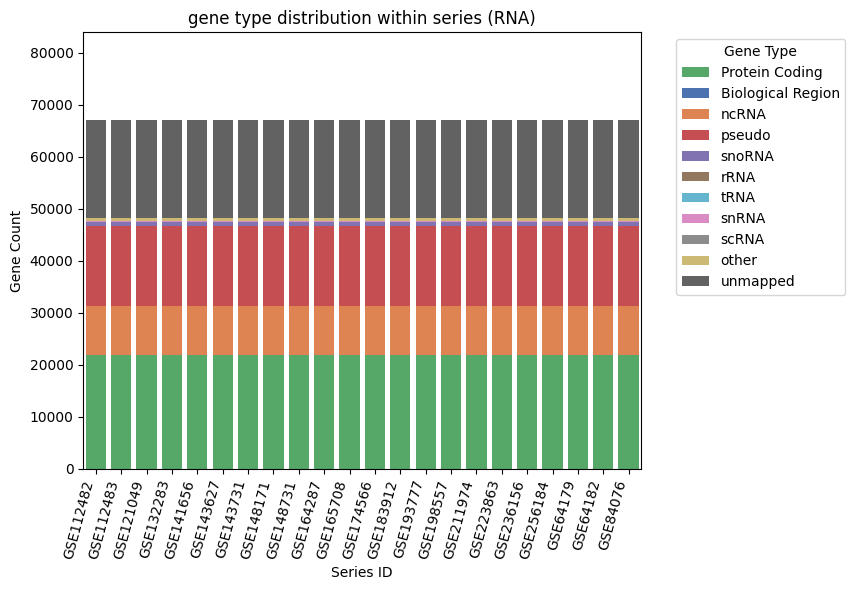

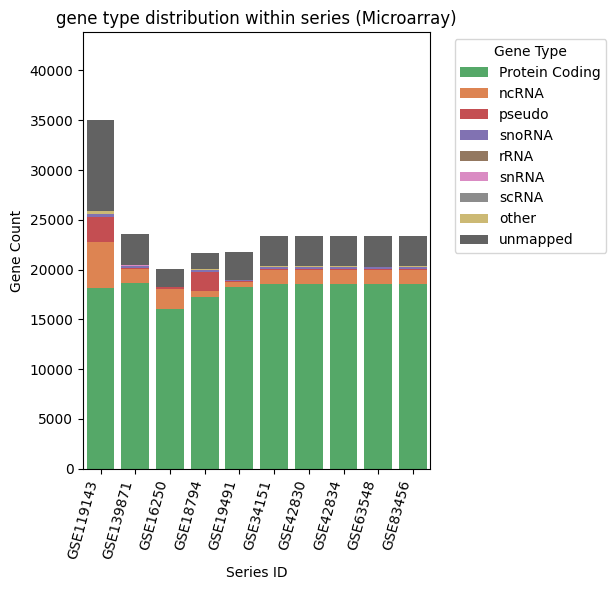

In [45]:
DISEASES = {
    'RNA': rnaRAW_path,
    'Microarray': microRAW_path,
}

# Define a consistent set of colors for the most common gene types observed 
GENE_TYPE_COLORS = {
    'protein-coding': '#55A868',     # balanced green
    'biological-region': '#4C72B0',  # soft blue
    'ncRNA': '#DD8452',              # warm amber
    'pseudo': '#C44E52',             # deep rose
    'snoRNA': '#8172B2',             # muted violet
    'rRNA': '#937860',               # earthy brown
    'tRNA': '#64B5CD',               # teal-blue
    'snRNA': '#DA8BC3',              # light magenta
    'scRNA': '#8C8C8C',              # neutral gray
    'other': '#CCB974',              # olive-gold
    'unmapped': "#626262"            # grey
}
# Define the preferred order for stacking and legend
ORDERED_TYPES = [
'protein-coding', 
'biological-region', 
'ncRNA', 
'pseudo', 
'snoRNA', 
'rRNA', 
'tRNA', 
'snRNA', 
'scRNA',
'other', 
'unmapped', 
]

def plot_gene_type_distribution(path_to_expression: str, disease: str, gene_to_type_map: Dict[str, str], colors: Dict[str, str], ordered_types: List[str]):
    """
    Creates a stacked histogram plot of the specific 'type_of_gene' distribution
    for each study (Series) in a given disease directory, by mapping the gene
    identifiers in the expression files to the provided gene_to_type_map.
    """
    
    if not os.path.exists(path_to_expression):
        print(f"Error: Directory not found for {disease}: {path_to_expression}")
        return

    files = [f for f in os.listdir(path_to_expression) if f.endswith('.tsv')]
    
    if not files:
        print(f"No TSV files found in {path_to_expression}. Skipping {disease}.")
        return

    all_gene_type_counts: Dict[str, Dict[str, int]] = {}
    study_names = []

    for file in files:
        file_path = os.path.join(path_to_expression, file)
        try:
            # gene name in col 1 
            df = pd.read_csv(file_path, sep='\t')
        except Exception as e:
            print(f"Error reading {file}: {e}")
            continue
        
        gene_col = df.columns[0]
        
        # Map the gene identifiers to their type, 'unmapped' if gene does not exist in the dict
        df['type_of_gene'] = df[gene_col].astype(str).map(lambda x: gene_to_type_map.get(x, 'unmapped'))
        
        # get count 
        counts = df.loc[df[gene_col].notna(), 'type_of_gene'].value_counts().to_dict()
        
        study_name = file.replace('.tsv', '')
        all_gene_type_counts[study_name] = counts
        study_names.append(study_name)

    # prep data for plotting
    if not all_gene_type_counts:
        print(f"No gene type data to plot for {disease}.")
        return

    # Create a consolidated DataFrame from the counts dictionary
    plot_df = pd.DataFrame.from_dict(all_gene_type_counts, orient='index').fillna(0)
    plot_df.index.name = 'study_name'
    plot_df = plot_df.sort_index()

    # Determine the actual types found, and reindex for consistent ordering
    # Ensure 'unmapped' is at the end if present
    actual_types = [t for t in ordered_types if t in plot_df.columns]
    if 'unmapped' in plot_df.columns and 'unmapped' not in actual_types:
        actual_types.append('unmapped')
    plot_df = plot_df.reindex(columns=actual_types, fill_value=0)

    # Plotting 
    study_names = plot_df.index.tolist()
    total_heights = plot_df.sum(axis=1).values
    max_height = total_heights.max() if len(total_heights) > 0 else 1

    plt.figure(figsize=(max(8, len(study_names)*0.5), 6))
    
    bottom_array = np.zeros(len(study_names))

    # Iterate through gene types in the ordered list to create the stacked bars
    for gene_type in actual_types:
        counts = plot_df[gene_type].values
        color = colors.get(gene_type, colors['other'])
        
        # Replace hyphens and capitalize for a clean legend label
        if '-' in gene_type:
            # For types like 'protein-coding'
            label = gene_type.replace('-', ' ').title()
        else:
            # For types like 'ncRNA', 'rRNA', 'pseudo'
            label = gene_type

        plt.bar(study_names, counts, bottom=bottom_array, 
                label=label, color=color)
        
        # Update the bottom for the next type
        bottom_array += counts

    # Finalize plot limits and labels
    plt.ylim(top=max_height * 1.25)
    plt.xlim([-0.5, len(study_names) - 0.5])
    
    plt.xticks(rotation=75, ha='right')
    plt.ylabel('Gene Count')
    plt.xlabel('Series ID')
    plt.title(f'gene type distribution within series ({disease})')
    
    # Place legend outside the plot area
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0), title="Gene Type")
    
    plt.tight_layout(rect=[0, 0, 0.8, 1]) 

    # Save the figure
    save_dir = 'images/GeneTypeDistribution'
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f'{save_dir}/{disease}_GeneTypeDistribution.png', dpi=300, bbox_inches='tight')
    plt.show()

# Use gene_to_type dict defined earlier
if 'gene_to_type' in globals() and isinstance(gene_to_type, dict) and gene_to_type:
    gene_map = gene_to_type
    print(f"Using existing gene_to_type map with {len(gene_map)} entries.")
    
    print("\nGenerating Stacked Gene Type Histograms for all diseases...")
    for disease, path in DISEASES.items():
        plot_gene_type_distribution(path, disease, gene_map, GENE_TYPE_COLORS, ORDERED_TYPES)
else:
    print("gene_to_type not found or empty. Cannot proceed with plotting.")

## Subset for protein coding genes only

In [46]:
# protein coding gene only
def filter_protein_coding_genes(expressionpath : str, gene_to_type: Dict[str, str], save : bool = False) -> pd.DataFrame:
	"""
	Given a path to an folder containing expression .tsv files, where dims are gene x samples,
	perform filtering to keep only protein coding genes based on gene_to_type mapping.

	if save is True, saves each DataFrames back to the same files, else returns a dictionary of filtered DataFrames.
	
	"""
	files = os.listdir(expressionpath)
	filtered_dfs = {}
	for file in files:
		if file.endswith('.tsv'):
			fpath = os.path.join(expressionpath, file)
			df = pd.read_csv(fpath, sep = '\t')
			gene_col = df.columns[0]
			# Identify protein-coding genes
			protein_coding_genes = [
				gene for gene in df[gene_col]
				if gene in gene_to_type and gene_to_type[gene] == 'protein-coding'
			]
			# Filter DataFrame
			filtered_df = df[df[gene_col].isin(protein_coding_genes)]
			if save:
				filtered_df.to_csv(fpath, sep = '\t', index = False)
			else:
				filtered_dfs[file] = filtered_df
	if not save:
		return filtered_dfs

#### Filter and save protein coding genes only

In [47]:
TB_filteredpc = filter_protein_coding_genes(rnaCLEAN_path, gene_to_type, save = True)

In [48]:
AST_filteredpc = filter_protein_coding_genes(microCLEAN_path, gene_to_type, save = True)

Using existing gene_to_type map with 299971 entries.

Generating Stacked Gene Type Histograms for all diseases...


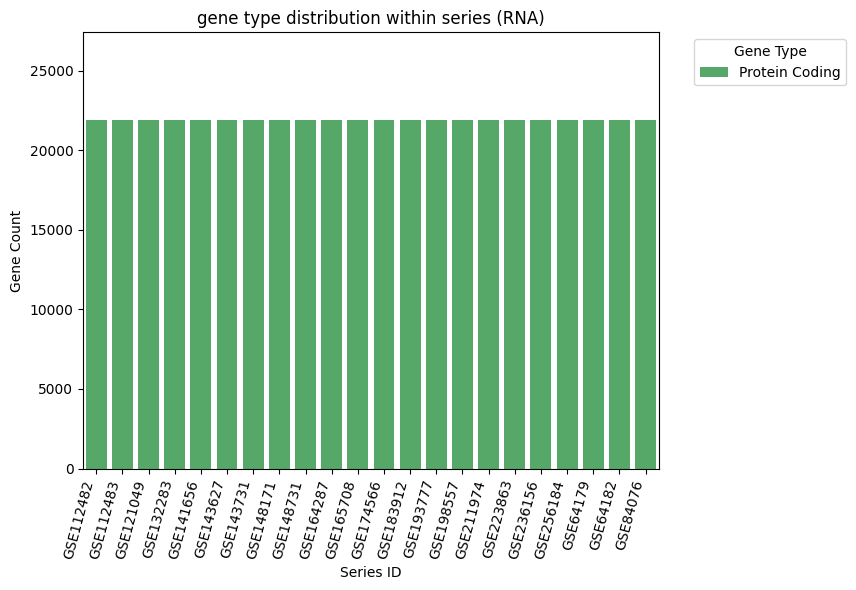

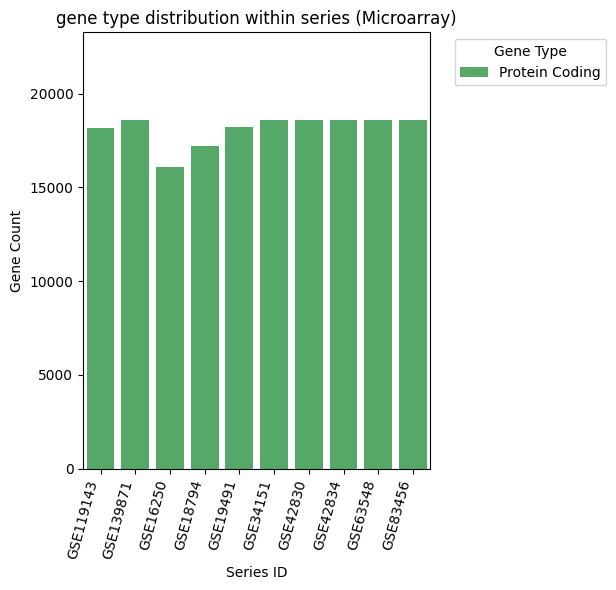

In [49]:
DISEASES = {
    'RNA': rnaCLEAN_path,
    'Microarray': microCLEAN_path,
}

if 'gene_to_type' in globals() and isinstance(gene_to_type, dict) and gene_to_type:
    gene_map = gene_to_type
    print(f"Using existing gene_to_type map with {len(gene_map)} entries.")
    
    print("\nGenerating Stacked Gene Type Histograms for all diseases...")
    for disease, path in DISEASES.items():
        plot_gene_type_distribution(path, disease, gene_map, GENE_TYPE_COLORS, ORDERED_TYPES)
else:
    print("gene_to_type not found or empty. Cannot proceed with plotting.")

# Function to remove low quality reads

## Remove low quality reads

- Rows where 50% or more of the columns is 0
- Rows where 90% or more of the row are 0
- Remove Rows where the gene name is missing or NaN

In [50]:
def remove_low_quality_reads(path, print_shape=False):
    """
    Cleans gene expression files by removing:
    - Columns where 50% or more of the columns is 0
    - Rows where 90% or more of the row are 0
    - Remove Rows where the gene name is missing or NaN
    Args:
        path (str): directory containing .tsv files
        print_shape (bool): if True, prints the shape of each cleaned DataFrame

    Returns:
        dict: cleaned DataFrames keyed by filename
    """
    cleaned_dfs = {}
    if not os.path.exists(path):
        print(f"Error: Path not found: {path}")
        return cleaned_dfs
        
    for file in os.listdir(path):
        if file.endswith('.tsv'):
            file_path = os.path.join(path, file)
            df = pd.read_csv(file_path, sep='\t')
            
            # remove rows where the gene name is na
            initial_row_count = df.shape[0]
            df = df[df.iloc[:, 0].notna()].copy()
            
            # Remove columns where 50% or more values are 0
            # Use all columns except the first for numeric operations
            numeric_cols_df = df.iloc[:, 1:] 
            
            # Identify columns to KEEP: where the number of zeros is LESS than 50% of the rows
            col_threshold = 0.5 * numeric_cols_df.shape[0] 
            # Filter keeps columns where zero count < threshold, which is correct
            cols_to_keep_mask = (numeric_cols_df == 0).sum(axis=0) < col_threshold 
            
            # Apply the filter to numeric columns and then concatenate with the first column
            numeric_cols_cleaned = numeric_cols_df.loc[:, cols_to_keep_mask]
            df_col_cleaned = pd.concat([df.iloc[:, [0]], numeric_cols_cleaned], axis=1)

            # remove rows where 90% or more values are 0 
            numeric_cols_df = df_col_cleaned.iloc[:, 1:]
            
            # Identify rows to KEEP: where the number of NON-ZEROS is GREATER than 10% of the columns
            # This is equivalent to removing rows where number of ZEROS is >= 90% of the columns.
            row_non_zero_threshold = 0.1 * numeric_cols_df.shape[1] 
            
            # mask counts non-zeros and checks if the count is > the 10% threshold (meaning < 90% zeros)
            mask = (numeric_cols_df != 0).sum(axis=1) > row_non_zero_threshold 
            
            df_cleaned = df_col_cleaned.loc[mask].copy()
            
            if print_shape:
                print(f"{file}: Original Shape ({initial_row_count}, {df.shape[1]}). Cleaned Shape {df_cleaned.shape}")
                
            cleaned_dfs[file] = df_cleaned
            
    return cleaned_dfs

# Function to remap the gene symbols to Ensembl IDs

**to be chained with remove_low_count_reads()**

```python
remapping(remove_low_count_reads())
```

In [51]:
def remapping(cleaned_dfs, output_path=None):
    """
    - Drops "linc" genes
    - Remaps gene using `symbol_to_ensg`
    - Keeps symbol for unmapped genes (no ENSG)
    - Drops duplicates after remapping
    - Optionally saves output
    - Prints a summary for each file

    Returns:
        dict: remapped and cleaned DataFrames
    """
    remapped_dfs = {}

    print(f"\n{'File':<20}{'Post-Filter':>12}{'LINC Dropped':>14}"
          f"{'Unmapped':>10}{'Post-Remap':>12}{'Duplicates':>12}"
          f"{'Final Rows':>12}")
    
    for filename, df in cleaned_dfs.items():
        df = df.copy()
        first_col = df.columns[0]
        pre_remap_rows = df.shape[0]

        # Drop 'linc' genes
        linc_mask = df[first_col].str.lower().str.startswith('linc')
        linc_count = linc_mask.sum()
        df = df.loc[~linc_mask].copy()

        # Remap: keep value if not in dict
        mapped = df[first_col].map(lambda x: symbol_to_ensg.get(x, x))
        unmapped_count = (~df[first_col].isin(symbol_to_ensg.keys())).sum()
        df.loc[:, first_col] = mapped

        # Count duplicates
        duplicate_count = df[first_col].duplicated().sum()
        post_remap_rows = df.shape[0]

        # Drop duplicates
        df = df.drop_duplicates(subset=[first_col])
        final_rows = df.shape[0]

        # Print report line
        print(f"{filename:<20}{pre_remap_rows:>12}{linc_count:>14}"
              f"{unmapped_count:>10}{post_remap_rows:>12}"
              f"{duplicate_count:>12}{final_rows:>12}")

        # Save if path is given
        if output_path:
            output_file = os.path.join(output_path, filename)
            df.to_csv(output_file, sep='\t', index=False)

        remapped_dfs[filename] = df

    return remapped_dfs

# Process all the expression data files

In [52]:
TBcleaned = remapping(remove_low_quality_reads(rnaCLEAN_path), rnaCLEAN_path)


File                 Post-Filter  LINC Dropped  Unmapped  Post-Remap  Duplicates  Final Rows
GSE236156.tsv              19111             4        97       19107        2224       16883
GSE164287.tsv              18940             4       104       18936        2172       16764
GSE148731.tsv              17980             4        78       17976        1957       16019
GSE183912.tsv              17618             4        80       17614        1899       15715
GSE211974.tsv              19003             4        85       18999        2093       16906
GSE132283.tsv              20579             5       118       20574        2282       18292
GSE165708.tsv              18767             4        83       18763        2140       16623
GSE143731.tsv              18644             4        83       18640        2048       16592
GSE174566.tsv              19872             4       136       19868        2462       17406
GSE256184.tsv              19742             5       116       19737 

In [53]:
ASTclean = remapping(remove_low_quality_reads(microCLEAN_path), microCLEAN_path)


File                 Post-Filter  LINC Dropped  Unmapped  Post-Remap  Duplicates  Final Rows
GSE42834.tsv               18590             0     18590       18590           0       18590
GSE34151.tsv               18590             0     18590       18590           0       18590
GSE42830.tsv               18590             0     18590       18590           0       18590
GSE16250.tsv               16082             0     16082       16082           0       16082
GSE139871.tsv              18623             0     18623       18623           0       18623
GSE18794.tsv               17215             0     17215       17215           0       17215
GSE119143.tsv              18158             0     18158       18158           0       18158
GSE19491.tsv               18217             0     18217       18217           0       18217
GSE83456.tsv               18590             0     18590       18590           0       18590
GSE63548.tsv               18589             0     18589       18589 

## Verify Integrity

* get a count of genes vs Ensemble IDs
* make sure there are no duplicate Ensemble IDs

In [54]:
def verify_process(path: str):
    """
    For each .tsv file in the given path:
    - Prints the total number of genes (rows)
    - Prints the number of Ensembl IDs (rows where first col starts with 'ENSG')
    - Prints the number of gene symbols (rows where first col does NOT start with 'ENSG')
    - Checks for duplicate Ensembl IDs
    - Checks for duplicate gene names (using symbol_alias mapping)
    - Prints if any file has duplicates before printing details
    """
    files = [f for f in os.listdir(path) if f.endswith('.tsv')]
    has_ensg_duplicates = False
    has_symbol_duplicates = False
    for file in files:
        df = pd.read_csv(os.path.join(path, file), sep='\t')
        gene_col = df.columns[0]
        ensg_mask = df[gene_col].astype(str).str.startswith('ENSG')
        # Check for duplicate Ensembl IDs
        if df.loc[ensg_mask, gene_col].duplicated().any():
            has_ensg_duplicates = True
        # Check for duplicate gene names (map all to canonical symbol, then check dups)
        mapped_symbols = df.loc[~ensg_mask, gene_col].map(lambda x: symbol_alias.get(x, x))
        if mapped_symbols.duplicated().any():
            has_symbol_duplicates = True
    
    print("Duplicates present in any file:" if has_ensg_duplicates or has_symbol_duplicates else "No duplicates found in any file.")
    if has_ensg_duplicates:
        print("- Duplicate Ensembl IDs found.")
    if has_symbol_duplicates:
        print("- Duplicate gene names (canonical symbol) found.")
    
    print(f"{'File':<20}{'Total Genes':>12}{'Ensembl IDs':>14}{'Gene Symbols':>14}{'ENSG Duplicates':>16}{'Symbol Duplicates':>18}")
    for file in files:
        df = pd.read_csv(os.path.join(path, file), sep='\t')
        gene_col = df.columns[0]
        total_genes = df.shape[0]
        ensg_mask = df[gene_col].astype(str).str.startswith('ENSG')
        ensg_count = ensg_mask.sum()
        symbol_count = total_genes - ensg_count
        ensg_duplicates = df.loc[ensg_mask, gene_col].duplicated().sum()
        mapped_symbols = df.loc[~ensg_mask, gene_col].map(lambda x: symbol_alias.get(x, x))
        symbol_duplicates = mapped_symbols.duplicated().sum()
        print(f"{file:<20}{total_genes:>12}{ensg_count:>14}{symbol_count:>14}{ensg_duplicates:>16}{symbol_duplicates:>18}")

In [55]:
verify_process(rnaCLEAN_path)

No duplicates found in any file.
File                 Total Genes   Ensembl IDs  Gene Symbols ENSG Duplicates Symbol Duplicates
GSE236156.tsv              16883         16860            23               0                 0
GSE164287.tsv              16764         16738            26               0                 0
GSE148731.tsv              16019         15999            20               0                 0
GSE183912.tsv              15715         15696            19               0                 0
GSE211974.tsv              16906         16884            22               0                 0
GSE132283.tsv              18292         18259            33               0                 0
GSE165708.tsv              16623         16601            22               0                 0
GSE143731.tsv              16592         16572            20               0                 0
GSE174566.tsv              17406         17378            28               0                 0
GSE256184.tsv    

In [56]:
verify_process(microCLEAN_path)

No duplicates found in any file.
File                 Total Genes   Ensembl IDs  Gene Symbols ENSG Duplicates Symbol Duplicates
GSE42834.tsv               18590         18590             0               0                 0
GSE34151.tsv               18590         18590             0               0                 0
GSE42830.tsv               18590         18590             0               0                 0
GSE16250.tsv               16082         16082             0               0                 0
GSE139871.tsv              18623         18623             0               0                 0
GSE18794.tsv               17215         17215             0               0                 0
GSE119143.tsv              18158         18158             0               0                 0
GSE19491.tsv               18217         18217             0               0                 0
GSE83456.tsv               18590         18590             0               0                 0
GSE63548.tsv     

#### Filter and save protein coding genes only

In [57]:
rna_filteredpc = filter_protein_coding_genes(rnaCLEAN_path, gene_to_type, save = True)

In [58]:
micro_filteredpc = filter_protein_coding_genes(microCLEAN_path, gene_to_type, save = True)

Using existing gene_to_type map with 299971 entries.

Generating Stacked Gene Type Histograms for all diseases...


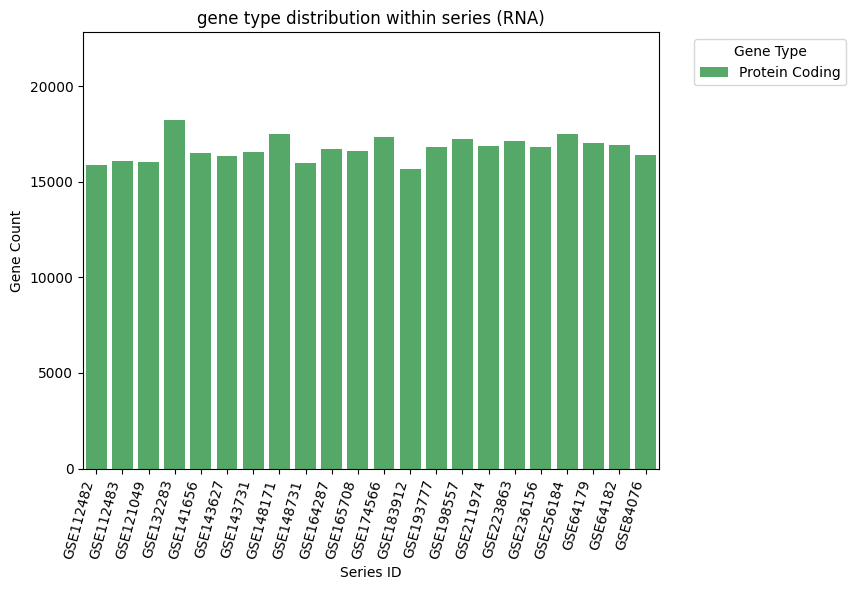

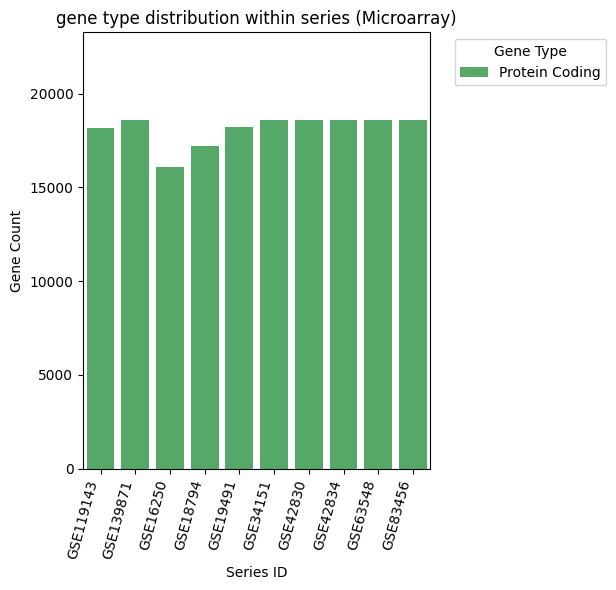

In [59]:
if 'gene_to_type' in globals() and isinstance(gene_to_type, dict) and gene_to_type:
    gene_map = gene_to_type
    print(f"Using existing gene_to_type map with {len(gene_map)} entries.")
    
    print("\nGenerating Stacked Gene Type Histograms for all diseases...")
    for disease, path in DISEASES.items():
        plot_gene_type_distribution(path, disease, gene_map, GENE_TYPE_COLORS, ORDERED_TYPES)
else:
    print("gene_to_type not found or empty. Cannot proceed with plotting.")